In [1]:
!pip install keras_facenet
import tensorflow as tf
from keras_facenet import FaceNet
import numpy as np
from tensorflow.keras import layers, models
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.cm as cm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.7 MB/s eta 0:00:00
  Created wheel for keras_facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=3cc2090da7e2450f58c7bca87905d7c68433bc15fee1c05fa2fcaa9639244098
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras_facenet


In [2]:
def resize_to_160(img):
    """
    img: Tensor or numpy array of shape (256, 256, 3)
    returns: Tensor (160, 160, 3)
    """
    img = tf.image.resize(img, (160, 160), method='bilinear')
    img = img.numpy()
    return img

In [3]:
def get_embedding(img):
  """
  The embedder.embeddings function expects a list of numpy arrays.
  img is already a numpy array from resize_to_160, so we wrap it in a list.
  """
  img = resize_to_160(img)
  emb = embedder.embeddings([img])[0]
  #emb = np.expand_dims(emb, axis=0)
  return emb

In [4]:
def process_row(row):
    row["embedding"] = resize_to_160(row["image"])
    return row

In [5]:
def get_embeddings(images):
  images = np.array(images['image'])
  embeddings = embedder.embeddings(images)
  #emb = np.expand_dims(emb, axis=0)
  return {"embedding": embeddings}

In [6]:
from datasets import load_dataset

ds = load_dataset("tonyassi/celebrity-1000")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18184 [00:00<?, ? examples/s]

In [7]:
ds['train'].shape

(18184, 2)

In [8]:
embedder = FaceNet()

In [9]:
num_of_classes = 10
keep = list(range(num_of_classes))
ds_50 = ds['train'].filter(lambda x: x["label"] in keep)


Filter:   0%|          | 0/18184 [00:00<?, ? examples/s]

In [10]:
ds_50 = ds_50.map(process_row)

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

In [11]:
ds_50 = ds_50.map(get_embeddings, batched=True)

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step


In [12]:
split_ds = ds_50.train_test_split(test_size=0.3, stratify_by_column="label",shuffle=True)
train = split_ds['train']
split_ds = split_ds['test'].train_test_split(test_size=2/3, shuffle=True)
test = split_ds['test']
val = split_ds['train']

In [13]:
print(train.shape)
print(test.shape)
print(val.shape)

(112, 3)
(32, 3)
(16, 3)


In [14]:
model = models.Sequential([
    layers.Input(shape=(512,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])


In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
x_train = np.array(train["embedding"])
y_train = np.array(train["label"])
x_val = np.array(val["embedding"])
y_val = np.array(val["label"])
x_test = np.array(test["embedding"])
y_test = np.array(test["label"])

In [17]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 607ms/step - accuracy: 0.2211 - loss: 2.2672 - val_accuracy: 0.6875 - val_loss: 2.1726
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7220 - loss: 2.1368 - val_accuracy: 0.9375 - val_loss: 2.0506
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9664 - loss: 1.9814 - val_accuracy: 1.0000 - val_loss: 1.9269
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9850 - loss: 1.8580 - val_accuracy: 1.0000 - val_loss: 1.7965
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9762 - loss: 1.7219 - val_accuracy: 1.0000 - val_loss: 1.6545
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9964 - loss: 1.5498 - val_accuracy: 1.0000 - val_loss: 1.5053
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9850 - loss: 1.4195 - val_accuracy: 1.0000 - val_loss: 1.3541
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9929 - loss: 1.2441 - val_accuracy: 1.0000 - val_loss: 1.2000

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,864 (784.63 KB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 133,910 (523.09 KB)

In [19]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9688 - loss: 0.8189
Accuracy: 0.96875


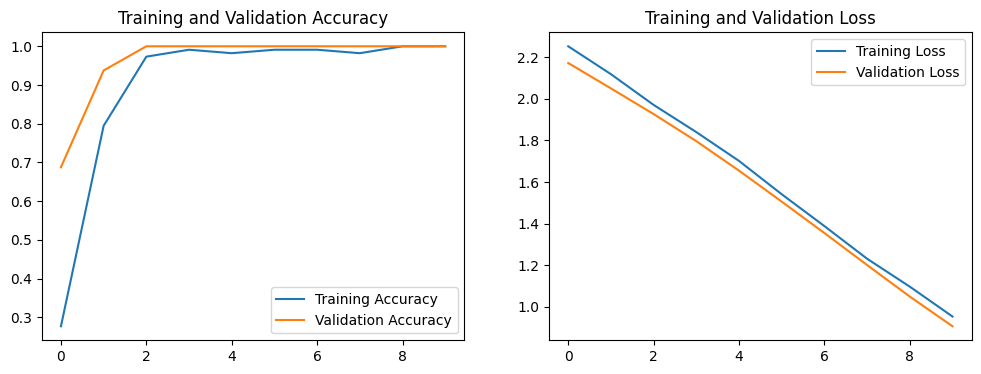

In [20]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


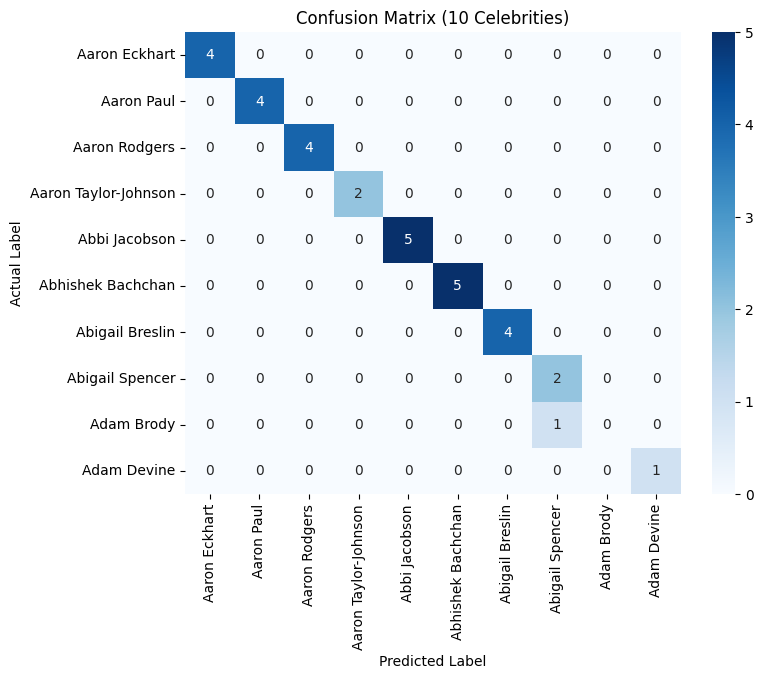

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = ds['train'].features['label'].names[:num_of_classes]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix (10 Celebrities)')
plt.xticks(rotation=90)
plt.show()

In [22]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=class_names)

print("Classification Report:\n")
print(report)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:

                      precision    recall  f1-score   support

       Aaron Eckhart       1.00      1.00      1.00         4
          Aaron Paul       1.00      1.00      1.00         4
       Aaron Rodgers       1.00      1.00      1.00         4
Aaron Taylor-Johnson       1.00      1.00      1.00         2
       Abbi Jacobson       1.00      1.00      1.00         5
   Abhishek Bachchan       1.00      1.00      1.00         5
     Abigail Breslin       1.00      1.00      1.00         4
     Abigail Spencer       0.67      1.00      0.80         2
          Adam Brody       0.00      0.00      0.00         1
         Adam Devine       1.00      1.00      1.00         1

            accuracy                           0.97        32
           macro avg       0.87      0.90      0.88        32
        weighted avg       0.95      0.97      0.96        32



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


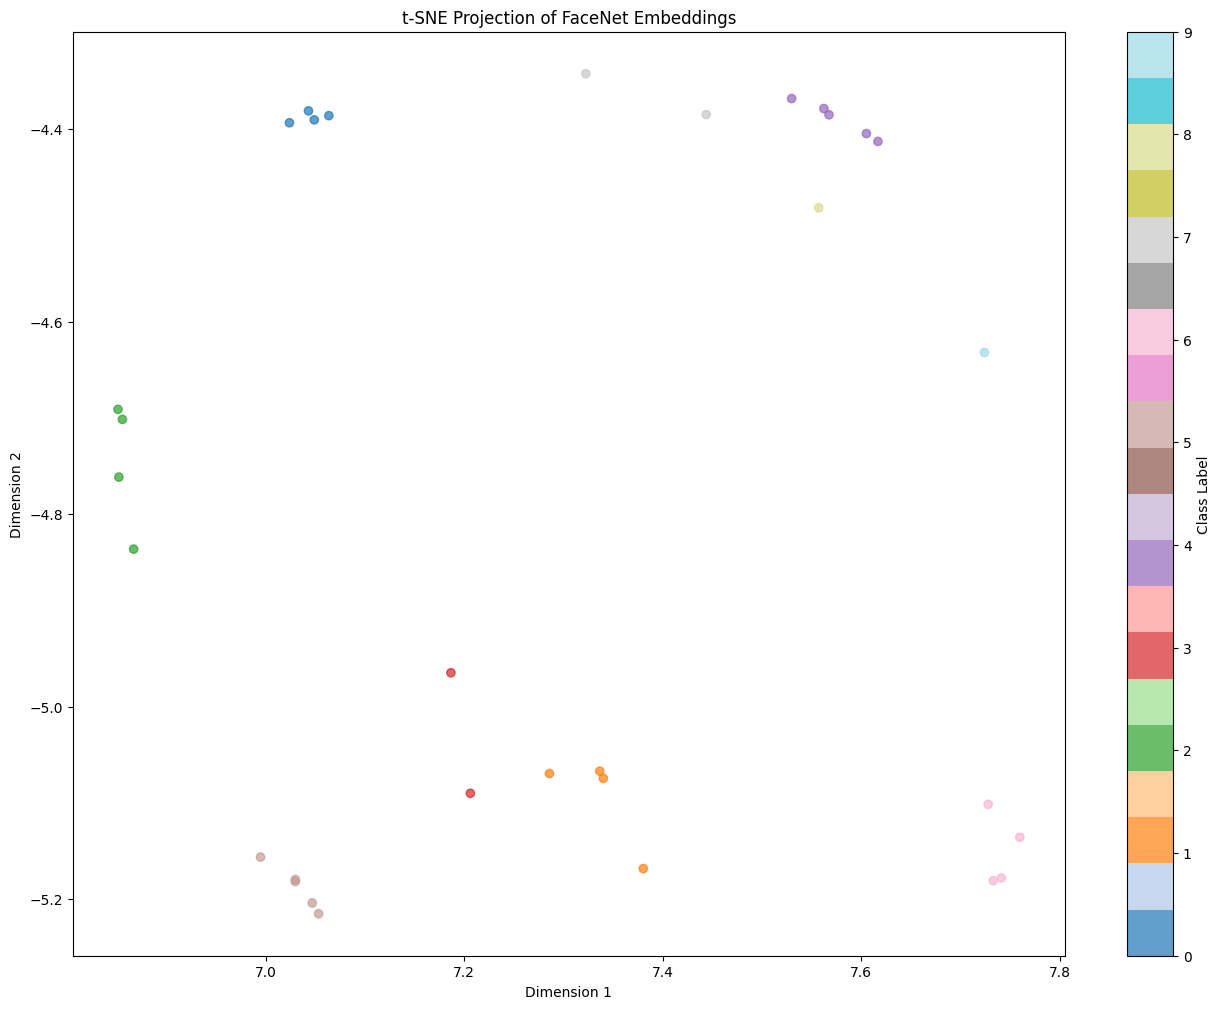

In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
x_test_2d = tsne.fit_transform(x_test)

plt.figure(figsize=(16, 12))
scatter = plt.scatter(x_test_2d[:, 0], x_test_2d[:, 1], c=y_test, cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Class Label')
plt.title('t-SNE Projection of FaceNet Embeddings')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

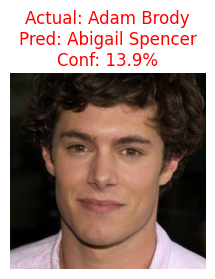

In [24]:
mistakes_idx = np.where(y_pred != y_test)[0]

num_mistakes = min(len(mistakes_idx), 10)

if num_mistakes > 0:
    plt.figure(figsize=(15, 5 * ((num_mistakes // 5) + 1)))
    for i, idx in enumerate(mistakes_idx[:num_mistakes]):
        ax = plt.subplot(2, 5, i + 1)

        img = test[int(idx)]['image']

        actual_name = class_names[y_test[idx]]
        pred_name = class_names[y_pred[idx]]
        confidence = np.max(y_pred_probs[idx]) * 100

        plt.imshow(img)
        plt.title(f"Actual: {actual_name}\nPred: {pred_name}\nConf: {confidence:.1f}%", color='red')
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Incredible! The model made 0 mistakes on the test set.")

In [25]:
def get_prediction(img):
  emb = get_embedding(img)
  emb = np.expand_dims(emb, axis=0)
  predictions = model.predict(emb)
  predicted_class = np.argmax(predictions)
  print(f"\nPredicted Class Index: {predicted_class}")
  print(f"Name: {ds['train'].features['label'].names[predicted_class]}")
  print(f"Confidence: {np.max(predictions) * 100:.2f}%")
  predictions = np.sort(predictions)[0,::-1]
  print(f"Top 10 Probabilities: {predictions[:10]}")
  return predicted_class

In [26]:
from mtcnn import MTCNN
import numpy as np
import cv2

detector = MTCNN()

def crop_face_mtcnn(img, required_size=(160, 160)):
    """
    Detects a face using MTCNN and returns a cropped RGB face.
    The input MUST be an RGB uint8 numpy array.
    """

    results = detector.detect_faces(img)
    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)
    x2 = min(x + w, img.shape[1])
    y2 = min(y + h, img.shape[0])

    face = img[y:y2, x:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)

    return face


Saving image.jpg to image.jpg


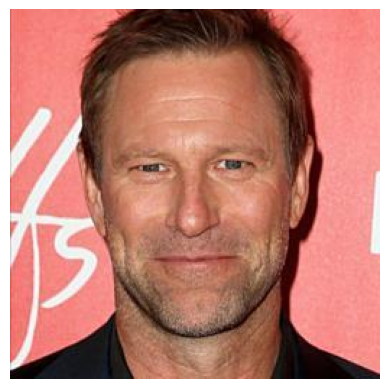

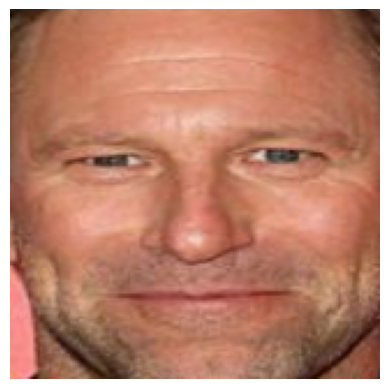

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step

Predicted Class Index: 0
Name: Aaron Eckhart
Confidence: 62.75%
Top 10 Probabilities: [0.6274763  0.06321633 0.05320763 0.04953011 0.04362028 0.03695083
 0.03467628 0.03374685 0.02943249 0.02814309]


In [27]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_pil = load_img(filename)
img = np.array(img_pil).astype('uint8')

plt.imshow(img)
plt.axis('off')
plt.show()

cropped = crop_face_mtcnn(img)

if cropped is not None:
  cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped)
  plt.axis('off')
  plt.show()
else:
  print("No face detected")

if cropped is None:
  print("No face detected")
else:
    pred_class = get_prediction(cropped)

In [31]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

model.save('/content/drive/My Drive/classifier.h5')

Mounted at /content/drive
